<a href="https://colab.research.google.com/github/Optimus0205/Employee-Attrition/blob/main/Project_2_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

whether an employee is likely to leave the company based on factors like
- job satisfaction,
- salary,
- work-life balance,
- years at the company,
- and performance ratings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Task 1 — Data Loading & Exploration
- Load the CSV file using Pandas



In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

- Display the first 10 rows

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,R&D,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,R&D,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,R&D,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,R&D,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,R&D,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,R&D,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,R&D,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,R&D,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,R&D,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


- Check how many rows and columns are there

In [4]:
df.shape

(1470, 35)

- Identify the target column (Attrition — Yes/No)

In [5]:
# y-> target column
x=df.drop('Attrition', axis=1)
y=df['Attrition']

- Count how many employees left vs stayed and calculate the attrition rate as a percentage

In [6]:
df_yes=df[df['Attrition']=='Yes']
df_yes['Attrition'].value_counts()

,count
Attrition,
Yes,237


In [7]:
df_yes['Attrition'].count()

np.int64(237)

In [8]:
(df_yes['Attrition'].count()/df['Attrition'].count())*100

np.float64(16.122448979591837)

In [9]:
df_no=df[df['Attrition']=='No']
df_no['Attrition'].value_counts()

,count
Attrition,
No,1233


In [10]:
(df_no['Attrition'].count()/df['Attrition'].count())*100

np.float64(83.87755102040816)

- Identify how many columns are numeric vs categorical

In [11]:
pd.DataFrame(df.dtypes, columns=['data_type']).groupby('data_type').value_counts()

,count
data_type,
int64,26
object,9


- Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?


The attrition rate is fully imbalance and reflects that most of the employees are not leaving the firm but there are still ~16% people who may leave the job

# Task 2 — Data Cleaning & Preprocessing
- Check for missing/null values and handle them


In [12]:
df.info()
# No missing or null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

- Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)


In [13]:
df=df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours'],axis=1)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,R&D,23,2,Medical,3,M,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,R&D,6,1,Medical,4,M,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,R&D,4,3,Life Sciences,2,M,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,M,...,3,4,0,17,3,2,9,6,0,8


- Convert the target column Attrition from Yes/No to 1/0

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Attrition']=le.fit_transform(df['Attrition'])
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,R&D,23,2,Medical,3,M,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,R&D,6,1,Medical,4,M,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,R&D,4,3,Life Sciences,2,M,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,M,...,3,4,0,17,3,2,9,6,0,8


- Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

In [16]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

categorical_columns=df.select_dtypes(include=['object']).columns
categorical_columns


encoded_df=pd.DataFrame(ohe.fit_transform(df[categorical_columns]).toarray(),columns=ohe.get_feature_names_out())
encoded_df

final_df=pd.concat([df.drop(categorical_columns,axis=1),encoded_df],axis=1)
final_df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,49,0,279,8,1,3,61,2,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,37,1,1373,2,2,4,92,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,33,0,1392,3,4,4,56,3,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,27,0,591,2,1,1,40,3,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1466,39,0,613,6,1,4,42,2,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1467,27,0,155,4,3,2,87,4,2,2,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1468,49,0,1023,2,3,4,63,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


- Scale numeric features using StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

df_scaled=scaler.fit_transform(final_df)
df_scaled=pd.DataFrame(df_scaled,columns=final_df.columns)
df_scaled

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,0.446350,2.280906,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
1,1.322365,-0.438422,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
2,0.008343,2.280906,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
3,-0.429664,-0.438422,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,-1.591746,1.591746
4,-1.086676,-0.438422,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,-0.438422,0.202082,1.703764,-0.891688,0.254625,-1.224807,1.785511,-0.057788,1.153254,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
1466,0.227347,-0.438422,-0.469754,-0.393938,-1.868426,1.169781,-1.175601,-1.026167,0.845911,-1.567907,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
1467,-1.086676,-0.438422,-1.605183,-0.640727,0.085049,-0.660531,1.038693,1.785511,-0.057788,-0.660853,...,3.022901,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,-1.591746,1.591746
1468,1.322365,-0.438422,0.546677,-0.887515,0.085049,1.169781,-0.142264,-1.026167,-0.057788,-0.660853,...,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241


#Task 3 — Exploratory Data Analysis — EDA
- Attrition rate by Department — which department loses the most employees?


In [53]:
df_department_status=df['Department'].groupby(df['Attrition']).value_counts().reset_index(name='count')
df_department_status

,Attrition,Department,count
0,0,R&D,828
1,0,Sales,354
2,0,HR,51
3,1,R&D,133
4,1,Sales,92
5,1,HR,12


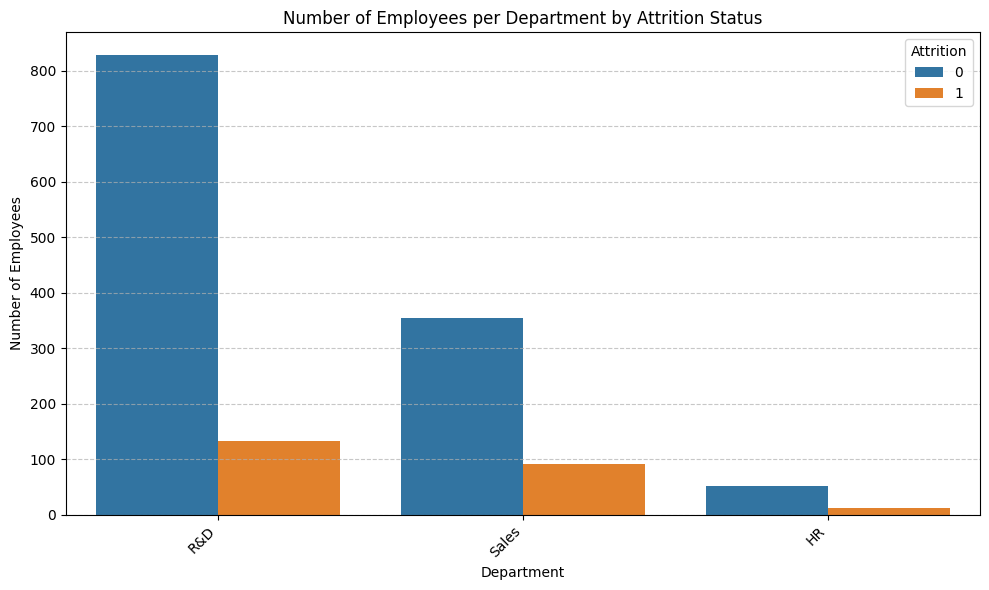

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_department_status, x='Department', y='count', hue='Attrition')

plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.title('Number of Employees per Department by Attrition Status')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- Attrition rate by Job Role — which roles have the highest exit rate?

In [19]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2


- Attrition vs Monthly Income — do lower paid employees leave more?
- Attrition vs Work-Life Balance rating — is there a visible pattern?
- Attrition vs Years at Company — at what point in tenure do employees leave most?
- Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)